In [29]:
fpath = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\bla.tif"
import csv

## Reconstruct path from dendrite
Home made strategy for this one could also exploit RESPAN output for that

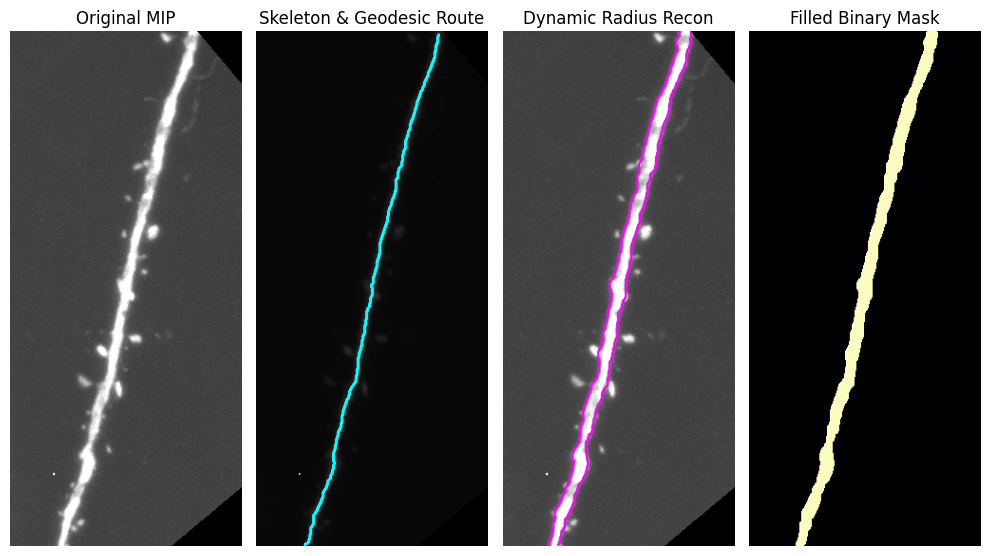

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.spatial.distance import pdist, squareform
from skimage import morphology, filters, measure, graph
import tifffile
from scipy.ndimage import label, center_of_mass

def reconstruct_shaft_geodesic(tiff_path):
    """
    Extracts the main dendrite shaft by routing a geodesic path down the 
    skeleton and dynamically reconstructing the volume using local radii.
    """
    # 1. Load and create a clean binary mask
    volume = tifffile.imread(tiff_path)
    mip = np.max(volume, axis=0) if volume.ndim == 3 else volume
    
    smoothed = filters.gaussian(mip.astype(float), sigma=1.0)
    binary_mask = smoothed > filters.threshold_otsu(smoothed)
    
    # Keep only the largest connected component to ignore floating noise
    labeled = measure.label(binary_mask)
    if labeled.max() == 0:
        return mip, binary_mask, binary_mask
    largest_cc = (labeled == np.argmax(np.bincount(labeled.flat)[1:]) + 1)
    
    # 2. Compute Distance Transform and Skeleton
    edt = ndi.distance_transform_edt(largest_cc)
    skel = morphology.skeletonize(largest_cc)
    
    # 3. Find Endpoints of the Skeleton
    # A skeleton endpoint has exactly 1 neighbor in a 3x3 grid
    kernel = np.array([[1, 1, 1], 
                       [1, 10, 1], 
                       [1, 1, 1]])
    neighbor_count = ndi.convolve(skel.astype(int), kernel, mode='constant')
    endpoints = np.argwhere((neighbor_count == 11) & skel)
    
    # Find the two endpoints furthest from each other (the start and end of the shaft)
    if len(endpoints) < 2:
        return mip, skel, largest_cc
        
    D = squareform(pdist(endpoints))
    i, j = np.unravel_index(np.argmax(D), D.shape)
    start_pt = tuple(endpoints[i])
    end_pt = tuple(endpoints[j])
    
    # 4. Geodesic Shortest Path (The Backbone)
    # Punish background pixels heavily so the route stays strictly on the skeleton
    cost_map = np.where(skel, 1, 1e6)
    path, _ = graph.route_through_array(cost_map, start=start_pt, end=end_pt, fully_connected=True)
    
    # 5. Medial Axis Reconstruction
    reconstructed_shaft = np.zeros_like(largest_cc)
    Y, X = np.indices(largest_cc.shape)
    
    # Redraw the shaft dynamically based on the exact radius at every backbone step
    for r, c in path:
        radius = edt[r, c]
        if radius > 0:
            # +0.5 prevents jagged sub-pixel digitization artifacts on the edges
            circle = (Y - r)**2 + (X - c)**2 <= (radius + 0.5)**2
            reconstructed_shaft |= circle
            
    return mip, skel, path, reconstructed_shaft

# --- Execution and Plotting ---
mip, skeleton, path, final_shaft = reconstruct_shaft_geodesic(fpath)
p_low = np.percentile(mip, 2)
p_high = np.percentile(mip, 98)

# Create a visual for the backbone path
path_img = np.zeros_like(mip, dtype=bool)
for r, c in path:
    path_img[r, c] = True

fig, axes = plt.subplots(1, 4, figsize=(10, 6))

axes[0].imshow(mip, cmap='gray', vmin=p_low, vmax=p_high)
axes[0].set_title('Original MIP')
axes[0].axis('off')

# Display the skeleton vs the calculated shortest path
axes[1].imshow(mip, cmap='gray')
axes[1].contour(path_img, colors='cyan', linewidths=1.5)
axes[1].set_title('Skeleton & Geodesic Route')
axes[1].axis('off')

# Display the exact physiological reconstruction (Outline)
axes[2].imshow(mip, cmap='gray', vmin=p_low, vmax=p_high)
axes[2].contour(final_shaft, colors='magenta', linewidths=1.5)
axes[2].set_title('Dynamic Radius Recon')
axes[2].axis('off')

# Display the Filled Binary Mask directly
axes[3].imshow(final_shaft, cmap='magma')
axes[3].set_title('Filled Binary Mask')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# --- Saving the Mask ---
# The boolean mask can be saved directly as a standard 8-bit TIFF
# final_shaft_uint8 = (final_shaft * 255).astype(np.uint8)
# tifffile.imwrite("filled_shaft_mask.tif", final_shaft_uint8)

In [31]:
import glob
import os 
folder = r'Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder'
tifffiles = glob.glob(folder+'/*.tif')
tifffiles
for i in tifffiles:
    mip, skeleton, path, final_shaft = reconstruct_shaft_geodesic(i)
    fname = os.path.basename(i).split('.tif')[0]+'_dendrite-geo.tif'
    expname = os.path.join(folder, fname)
    print(expname)
    final_shaft_uint8 = (final_shaft * 255).astype(np.uint8)
    tifffile.imwrite(expname, final_shaft_uint8)

Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\blm2_dendrite-geo.tif
Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\blm1_dendrite-geo.tif
Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\bla_dendrite-geo.tif


## Exploit RESPAN resources

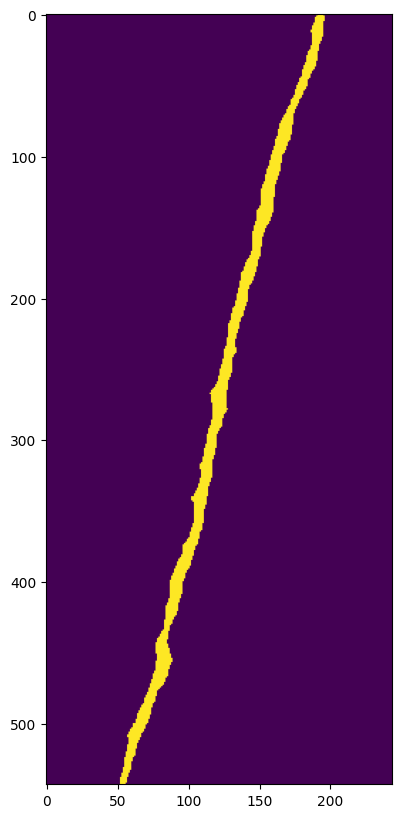

In [32]:
fig, axes = plt.subplots(1, 1, figsize=(15, 10))
val=1
respanseg = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\Segmentation_Labels\croppedsegment.tif"
stack = tifffile.imread(respanseg)
binary_mask = (stack == val)
structure_2d = np.ones((3, 3), dtype=int)
structure_3d = np.ones((3, 3, 3), dtype=int)
if val == 1:
    # Use structure_3d so diagonal 3D voxels are grouped as one object
    labeled_mask_3d, num_objects_3d = label(binary_mask, structure=structure_3d)
    if num_objects_3d > 0:
        sizes = np.bincount(labeled_mask_3d.ravel())
        sizes[0] = 0  # Ignore the background
        largest_label = sizes.argmax()
        binary_mask = (labeled_mask_3d == largest_label)
mip_2d = np.max(binary_mask, axis=0)
out_image = (mip_2d.astype(np.uint8) * 255)
out_tiff_name =r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\test.tif"
tifffile.imwrite(out_tiff_name, out_image)
plt.imshow(out_image)
plt.show()

In [33]:
# glob.glob(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder (respan batch test)\**\Segmentation_Labels\")
# fname = os.path.basename(file_path).split('.tif')[0]
# folder = r'Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder'
# respanfolder = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder (respan batch test)"
# tifffiles = glob.glob(folder+'/*.tif')
# tifffiles
# for i in tifffiles:
#     print(i)


fname = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\bla.tif"
fname = os.path.basename(fname)
glob.glob(f'{respanfolder}/**/*/Segmentation_Labels/{fname}')[0]


'Z:\\2026 - E19 Project collab spine and dendrites\\Respan\\202607013_makingCAREmodel_deconvolution+GaussianFilter\\nocare_MS\\TEST1\\New folder (respan batch test)\\test1\\Validation_Data\\Segmentation_Labels\\bla.tif'

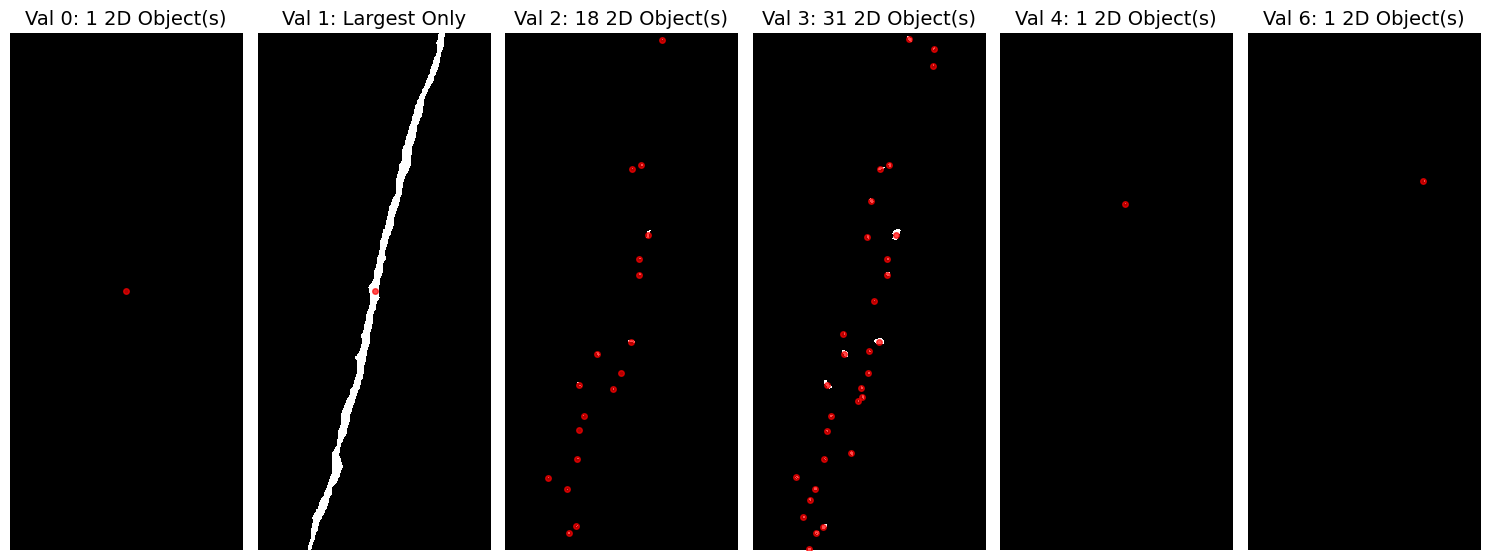

In [34]:


respanseg = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\Segmentation_Labels\croppedsegment.tif"

stack = tifffile.imread(respanseg)
unique_values = np.unique(stack)
unique_values
# 2. Set up a plotting grid (2 rows, 3 columns for 6 images)
fig, axes = plt.subplots(1, len(unique_values), figsize=(15, 10))
axes = axes.flatten() # Flatten to make it easier to iterate through
# Initialize list to hold our CSV rows, starting with headers
csv_data = [['Value', 'Object_ID', 'Y_Center', 'X_Center']]
structure_2d = np.ones((3, 3), dtype=int)
structure_3d = np.ones((3, 3, 3), dtype=int)
# 3. Process each unique value
for i, val in enumerate(unique_values):
    if i >= 6: 
        break 

    # Step A: Create a 3D binary mask
    binary_mask = (stack == val)
    
    # --- Filter: Keep only the largest 3D object for value 1 ---
    if val == 1:
        # Use structure_3d so diagonal 3D voxels are grouped as one object
        labeled_mask_3d, num_objects_3d = label(binary_mask, structure=structure_3d)
        if num_objects_3d > 0:
            sizes = np.bincount(labeled_mask_3d.ravel())
            sizes[0] = 0  # Ignore the background
            largest_label = sizes.argmax()
            binary_mask = (labeled_mask_3d == largest_label)
    # -----------------------------------------------------------

    # Step B: Create the 2D MIP *FIRST*
    mip_2d = np.max(binary_mask, axis=0)
    
    # Step C: Identify distinct objects on the flat 2D MIP
    # Use structure_2d to fix the diagonal corner issue
    labeled_mip, num_objects = label(mip_2d, structure=structure_2d)
    
    centers_of_mass = []
    if num_objects > 0:
        # Step D: Calculate center of mass on the 2D image
        object_ids = list(range(1, num_objects + 1))
        
        centers_of_mass = center_of_mass(mip_2d, labels=labeled_mip, index=object_ids)
        
        # Add the results to our CSV data list
        for obj_idx, com in enumerate(centers_of_mass):
            if not np.isnan(com[0]):
                com_y, com_x = com[0], com[1]
                csv_data.append([val, obj_idx + 1, round(com_y, 2), round(com_x, 2)])

    # Step E: Plot the 2D MIP and the centers
    ax = axes[i]
    ax.imshow(mip_2d, cmap='gray', interpolation='none') 
    
    for com in centers_of_mass:
        if not np.isnan(com[0]):
            com_y, com_x = com[0], com[1]
            ax.plot(com_x, com_y, marker='o', color='red', markersize=4, alpha=0.7)
    
    title = f'Val {val}: {num_objects} 2D Object(s)' if val != 1 else f'Val 1: Largest Only'
    ax.set_title(title, fontsize=14)
    ax.axis('off') 

plt.tight_layout()

# # 4. Save Outputs
# plot_filename = 'mip_results.png'
# plt.savefig(plot_filename, dpi=300, bbox_inches='tight')

# csv_filename = 'seed_coordinates.csv'
# with open(csv_filename, mode='w', newline='') as file:
#     writer = csv.writer(file)
#     writer.writerows(csv_data)

In [35]:
def extract_and_save_seeds(val, out_csv_name):
    print(f"Processing Value {val} (2D MIP Seeds)...")
    mask = (stack == val)
    mip_2d = np.max(mask, axis=0)
    labeled_mip, num_objects = label(mip_2d, structure=structure_2d)
    
    csv_data = [['Value', 'Object_ID', 'Y_Center', 'X_Center']]
    
    if num_objects > 0:
        object_ids = list(range(1, num_objects + 1))
        centers = center_of_mass(mip_2d, labels=labeled_mip, index=object_ids)
        
        for obj_idx, com in enumerate(centers):
            if not np.isnan(com[0]):
                com_y, com_x = com[0], com[1]
                csv_data.append([val, obj_idx + 1, round(com_y, 2), round(com_x, 2)])
    
    # Write to CSV
    with open(out_csv_name, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerows(csv_data)
        
        print(f"  -> Saved {out_csv_name} ({num_objects} objects found)")
        print(csv_data)

In [36]:
def process_tiff_targets_respan(file_path, respanfolder):
    """
    Reads a TIFF stack and extracts specific targets:
    - Value 1: Isolates the largest 3D object, creates a 2D MIP, and saves as a TIFF.
    - Value 2 & 3: Calculates 2D MIP centers of mass and saves them as separate CSVs.
    """
    
    fname = os.path.basename(file_path)
    respanfile = glob.glob(f'{respanfolder}/**/*/Segmentation_Labels/{fname}')[0]
    
    print(f"Loading {respanfile}...")
    stack = tifffile.imread(respanfile)

    # Define 8-connectivity structures
    structure_3d = np.ones((3, 3, 3), dtype=int)
    structure_2d = np.ones((3, 3), dtype=int)

    # ==========================================
    # TARGET 1: Largest Object (Saved as 2D MIP)
    # ==========================================
    print("Processing Value 1 (Largest Object -> 2D MIP)...")
    
    val = 1
    binary_mask = (stack == val)
    structure_2d = np.ones((3, 3), dtype=int)
    structure_3d = np.ones((3, 3, 3), dtype=int)
    if val == 1:
        # Use structure_3d so diagonal 3D voxels are grouped as one object
        labeled_mask_3d, num_objects_3d = label(binary_mask, structure=structure_3d)
        if num_objects_3d > 0:
            sizes = np.bincount(labeled_mask_3d.ravel())
            sizes[0] = 0  # Ignore the background
            largest_label = sizes.argmax()
            binary_mask = (labeled_mask_3d == largest_label)
        mip_2d = np.max(binary_mask, axis=0)

        # Setup the output file path
        folder = os.path.dirname(file_path)
        fname = os.path.basename(file_path).split('.tif')[0] + '_dendrite-respan.tif'
        out_tiff_name = os.path.join(folder, fname)
    
        # Save the 2D mask as a standard TIFF 
        tifffile.imwrite(out_tiff_name, out_image)
        print(f"  -> Saved {out_tiff_name}")


    # ==========================================
    # TARGET 2 & 3: 2D MIP Seeds
    # ==========================================
    for val in [2,3]:
        mask = (stack == val)
        # print(mask)
        mip_2d = np.max(mask, axis=0)
        labeled_mip, num_objects = label(mip_2d, structure=structure_2d)

        csv_data = [['Value', 'Object_ID', 'y', 'x']]

        if num_objects > 0:
            object_ids = list(range(1, num_objects + 1))
            centers = center_of_mass(mip_2d, labels=labeled_mip, index=object_ids)
            # print(centers)
            for obj_idx, com in enumerate(centers):
                if not np.isnan(com[0]):
                    com_y, com_x = com[0], com[1]
                    csv_data.append([val, obj_idx + 1, round(com_y, 2), round(com_x, 2)])
        
        fname = os.path.basename(file_path).split('.tif')[0]+f'_seeds_{val}-respan.csv'
        out_csv_name = os.path.join(folder, fname)
        # Write to CSV
        with open(out_csv_name, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerows(csv_data)
        
        print(f"  -> Saved {out_csv_name} ({num_objects} objects found)")
        # print(csv_data)

    # Run the seed extraction for values 2 and 3


    print("\nProcessing complete!")

## Code usage for dual extraction

In [37]:
import glob
import os 
folder = r'Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder'
respanfolder = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder (respan batch test)"
tifffiles = glob.glob(folder+'/*.tif')
tifffiles
for i in tifffiles:
    mip, skeleton, path, final_shaft = reconstruct_shaft_geodesic(i)
    fname = os.path.basename(i).split('.tif')[0]+'_dendrite-geo.tif'
    expname = os.path.join(folder, fname)
    print(expname)
    final_shaft_uint8 = (final_shaft * 255).astype(np.uint8)
    tifffile.imwrite(expname, final_shaft_uint8)
    process_tiff_targets_respan(i,respanfolder)

Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\blm2_dendrite-geo.tif
Loading Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder (respan batch test)\test1\Validation_Data\Segmentation_Labels\blm2.tif...
Processing Value 1 (Largest Object -> 2D MIP)...
  -> Saved Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\blm2_dendrite-respan.tif
  -> Saved Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\blm2_seeds_2-respan.csv (18 objects found)
  -> Saved Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\blm2_seeds_3-respan.csv (31 objects found)

Processing c

IndexError: list index out of range

## older approach

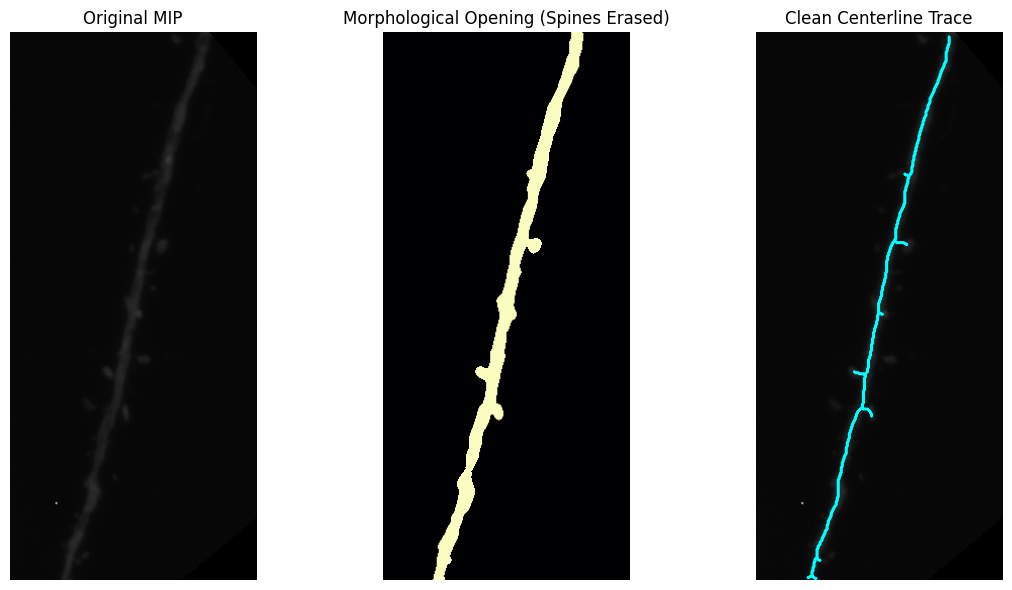

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure
import tifffile

def extract_clean_shaft_centerline(tiff_path, spine_radius_px=4):
    """
    Extracts a clean, single-line skeleton of the dendrite shaft,
    using morphological opening to physically erase spine protrusions.
    """
    # 1. Load the Z-stack and generate the MIP
    volume = tifffile.imread(tiff_path)
    if volume.ndim == 3:
        mip = np.max(volume, axis=0).astype(float)
    else:
        mip = volume.astype(float)
        
    # 2. Gaussian Blur to smooth intensity variations
    smoothed = filters.gaussian(mip, sigma=2.0)
    
    # 3. Thresholding (Otsu)
    thresh_val = filters.threshold_otsu(smoothed)
    binary_mask = smoothed > thresh_val
    
    # 4. THE SPINE KILLER: Morphological Opening
    # This erases any structure smaller than the footprint.
    # Adjust 'spine_radius_px' so it is larger than your biggest spine width
    # but smaller than the thickness of the main dendritic shaft.
    footprint = morphology.disk(spine_radius_px)
    shaft_only = morphology.opening(binary_mask, footprint)
    
    # 5. Isolate the largest connected component 
    # (Removes any floating disconnected spine heads that survived)
    labeled_image = measure.label(shaft_only, connectivity=2)
    if labeled_image.max() == 0:
        return mip, np.zeros_like(mip, dtype=bool) # Returns empty if nothing detected
        
    # Find the label with the largest area
    regions = measure.regionprops(labeled_image)
    largest_region = max(regions, key=lambda x: x.area)
    clean_shaft_mask = (labeled_image == largest_region.label)
    
    # 6. Skeletonize the cleaned shaft
    centerline = morphology.skeletonize(clean_shaft_mask)
    
    return mip, clean_shaft_mask, centerline

# --- Execution and Plotting ---
# Replace with your actual TIFF filename
mip, clean_shaft, centerline = extract_clean_shaft_centerline(path, spine_radius_px=4)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mip, cmap='gray')
axes[0].set_title('Original MIP')
axes[0].axis('off')

axes[1].imshow(clean_shaft, cmap='magma')
axes[1].set_title('Morphological Opening (Spines Erased)')
axes[1].axis('off')

axes[2].imshow(mip, cmap='gray')
axes[2].contour(centerline, colors='cyan', linewidths=1.5)
axes[2].set_title('Clean Centerline Trace')
axes[2].axis('off')

plt.tight_layout()
plt.show()